In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# 引用我們剛剛建立的 model.py
from model_v15 import NFSTNDTModelV15
# 引用您原本專案中的 utils 和 trainer
from utils import * 
from trainer import Trainer

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Parameters
dataset_name = 'beignet' #affi' # 或 'beignet'
if dataset_name == 'beignet':
    num_channels = 89
else:
    num_channels = 239

batch_size = 16
num_epochs = 100
learning_rate = 1e-4
hidden_size = 256
n_heads = 4
n_layers = 3
dropout = 0.1
quantiles = [0.1, 0.5, 0.9]
INIT_STEPS = 10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load Data
raw = np.load(f'dataset/train_data_{dataset_name}.npz')['arr_0']
num_total = len(raw)
train_end = int(num_total * 0.8)
val_end = int(num_total * 0.9)

train_data = raw[:train_end]
val_data = raw[train_end:val_end]
test_data = raw[val_end:]

print(f"Data split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

Data split: Train=560, Val=70, Test=70


In [3]:
# Dataset Initialization
# 注意：這裡假設 NeuroForcastDataset 在 utils.py 中定義
# Dataset
train_ds = NeuroForcastDataset(train_data, use_graph=False)
# 儲存統計數據供反標準化使用
np.savez(f'train_data_average_std_{dataset_name}.npz', average=train_ds.average, std=train_ds.std)

test_ds = NeuroForcastDataset(test_data, use_graph=False, average=train_ds.average, std=train_ds.std)
val_ds = NeuroForcastDataset(val_data, use_graph=False, average=train_ds.average, std=train_ds.std)

train_data_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_data_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
val_data_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

# 計算鄰接矩陣 (GCN 核心)
threshold = 0.1
adj_matrix = compute_adj_matrix(train_data, threshold=threshold).to(DEVICE)
print(f"Adjacency Matrix shape: {adj_matrix.shape}")

Adjacency Matrix shape: torch.Size([89, 89])


In [4]:
# 初始化模型 (直接使用 model.py 中的類別)
model = NFSTNDTModelV15(
    input_size=num_channels,
    hidden_size=hidden_size,
    n_heads=n_heads,
    n_layers=n_layers,
    dropout=dropout,
    num_features=9,
    use_time2vec=True,
    time2vec_k=8,
    use_delta_t=True,
    quantiles=quantiles,
    adj=adj_matrix
).to(DEVICE)

print("Model initialized.")

Model initialized.


In [5]:
# 計算 Spike Threshold (tau)
f0 = train_data[..., 0]
dy = f0[:, 1:, :] - f0[:, :-1, :]
abs_dy = np.abs(dy.reshape(-1))
tau = float(np.percentile(abs_dy, 95))
print(f"Spike threshold tau: {tau:.6f}")

spike_weight = 2.0
lambda_change = 0.2
change_loss_fn = torch.nn.L1Loss(reduction="none")

def pinball_loss(y_hat, y, q):
    e = y - y_hat
    return torch.maximum(q * e, (q - 1.0) * e)

def quantile_order_penalty(q10, q50, q90):
    return (F.relu(q10 - q50).mean() + F.relu(q50 - q90).mean())

def spike_aware_loss_v9_1(pred_tensor, target, init_steps=10):
    Q = len(quantiles)
    y_pred = pred_tensor[..., :Q]   
    dy_pred = pred_tensor[..., Q]   
    y_true = target                 

    dy_true = y_true[:, 1:, :] - y_true[:, :-1, :]
    dy_true = torch.cat([dy_true[:, :1, :], dy_true], dim=1)

    spike_mask = (torch.abs(dy_true) > tau).float()
    w = 1.0 + spike_mask * (spike_weight - 1.0)

    q_losses = []
    for k, q in enumerate(quantiles):
        q_loss = pinball_loss(y_pred[..., k], y_true, q)
        q_losses.append((q_loss * w).mean())
    quant_loss = sum(q_losses) / len(q_losses)

    q10, q50, q90 = y_pred[..., 0], y_pred[..., 1], y_pred[..., 2]
    ord_loss = quantile_order_penalty(q10, q50, q90)

    change_loss = (change_loss_fn(dy_pred, dy_true) * w).mean()

    total_loss = (1.0 * quant_loss + lambda_change * change_loss + 5.0 * ord_loss)
    return total_loss

def spike_aware_loss_v9_1_mse(pred_tensor, target, init_steps=10):
    """
    pred_tensor: (B, T, C, Q+1)
    target:      (B, T, C)
    """
    Q = len(quantiles)
    y_pred = pred_tensor[..., :Q]   
    dy_pred = pred_tensor[..., Q]   
    y_true = target                 

    # 1. 計算真實變化量
    dy_true = y_true[:, 1:, :] - y_true[:, :-1, :]
    dy_true = torch.cat([dy_true[:, :1, :], dy_true], dim=1)

    # 2. Spike 加權 (專注於突發變化)
    spike_mask = (torch.abs(dy_true) > tau).float()
    w = 1.0 + spike_mask * (spike_weight - 1.0)

    # 3. Quantile Loss (Pinball) - 保持原本的區間預測能力
    q_losses = []
    for k, q in enumerate(quantiles):
        q_loss = pinball_loss(y_pred[..., k], y_true, q)
        q_losses.append((q_loss * w).mean())
    quant_loss = sum(q_losses) / len(q_losses)

    # 4. Ordering Penalty (防止區間錯亂)
    q10, q50, q90 = y_pred[..., 0], y_pred[..., 1], y_pred[..., 2]
    ord_loss = quantile_order_penalty(q10, q50, q90)

    # 5. Change Loss (幫助抓 Spike)
    change_loss = (change_loss_fn(dy_pred, dy_true) * w).mean()

    # --- 【關鍵新增】Anchor Loss (MSE) ---
    # 強制中位數 (index 1) 必須最小化 MSE
    # 這會讓預測值更精準地貼近真實值，大幅降低 MSR
    mse_anchor = torch.mean(((y_true - q50)**2) * w)

    # 總 Loss (稍微調高 MSE 的權重)
    # 建議權重: Quantile=1.0, Change=0.2, Order=5.0, MSE=10.0
    total_loss = (
        1.0 * quant_loss + 
        0.2 * change_loss + 
        5.0 * ord_loss + 
        10.0 * mse_anchor  # <--- 加入這項！
    )
    return total_loss


# loss_fn = lambda y_hat, y_true: spike_aware_loss_v9_1(y_hat, y_true, init_steps=10)
loss_fn = lambda y_hat, y_true: spike_aware_loss_v9_1_mse(y_hat, y_true, init_steps=10)

Spike threshold tau: 280.900000


In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
lambda1 = lambda epoch: 0.95 ** (epoch // 20)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda1)
save_path = f'./model_{dataset_name}_v15.pth'

trainer = Trainer(
    model=model,
    train_data_loader=train_data_loader,
    test_data_loader=test_data_loader,
    val_data_loader=val_data_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=DEVICE,
    scheduler=scheduler,
    forecasting_mode='multi_step',
    init_steps=10,
    save_path=save_path,
    ckpt_path=None,
    max_grad_norm=1.0,
    validate_every=1,
    save_best=True
)

trainer.train(num_epochs)
print("Best val:", trainer.best_val)

Epoch 2/100:   6%|▌         | 2/35 [00:00<00:02, 13.17it/s, train_loss=2.098247, lr=3.00e-04]

Epoch 000 | lr=3.000000e-04 | Train=7.005389 | Val=0.830636
Saving keys: ['adj', 'time2vec.w0', 'time2vec.b0', 'time2vec.w', 'time2vec.b', 'in_proj.weight', 'in_proj.bias', 'encoder.layers.0.self_attn.in_proj_weight', 'encoder.layers.0.self_attn.in_proj_bias', 'encoder.layers.0.self_attn.out_proj.weight', 'encoder.layers.0.self_attn.out_proj.bias', 'encoder.layers.0.linear1.weight', 'encoder.layers.0.linear1.bias', 'encoder.layers.0.linear2.weight', 'encoder.layers.0.linear2.bias', 'encoder.layers.0.norm1.weight', 'encoder.layers.0.norm1.bias', 'encoder.layers.0.norm2.weight', 'encoder.layers.0.norm2.bias', 'encoder.layers.1.self_attn.in_proj_weight']
[BEST] Saved to ./model_beignet_v15.pth | best_val=0.830636


Epoch 3/100:   6%|▌         | 2/35 [00:00<00:02, 13.13it/s, train_loss=1.168510, lr=3.00e-04]

Epoch 001 | lr=3.000000e-04 | Train=0.799171 | Val=0.545022
Saving keys: ['adj', 'time2vec.w0', 'time2vec.b0', 'time2vec.w', 'time2vec.b', 'in_proj.weight', 'in_proj.bias', 'encoder.layers.0.self_attn.in_proj_weight', 'encoder.layers.0.self_attn.in_proj_bias', 'encoder.layers.0.self_attn.out_proj.weight', 'encoder.layers.0.self_attn.out_proj.bias', 'encoder.layers.0.linear1.weight', 'encoder.layers.0.linear1.bias', 'encoder.layers.0.linear2.weight', 'encoder.layers.0.linear2.bias', 'encoder.layers.0.norm1.weight', 'encoder.layers.0.norm1.bias', 'encoder.layers.0.norm2.weight', 'encoder.layers.0.norm2.bias', 'encoder.layers.1.self_attn.in_proj_weight']
[BEST] Saved to ./model_beignet_v15.pth | best_val=0.545022


Epoch 4/100:   6%|▌         | 2/35 [00:00<00:02, 13.09it/s, train_loss=0.795631, lr=3.00e-04]

...

Epoch 097 | lr=2.443519e-04 | Train=0.206681 | Val=0.194256
Saving keys: ['adj', 'time2vec.w0', 'time2vec.b0', 'time2vec.w', 'time2vec.b', 'in_proj.weight', 'in_proj.bias', 'encoder.layers.0.self_attn.in_proj_weight', 'encoder.layers.0.self_attn.in_proj_bias', 'encoder.layers.0.self_attn.out_proj.weight', 'encoder.layers.0.self_attn.out_proj.bias', 'encoder.layers.0.linear1.weight', 'encoder.layers.0.linear1.bias', 'encoder.layers.0.linear2.weight', 'encoder.layers.0.linear2.bias', 'encoder.layers.0.norm1.weight', 'encoder.layers.0.norm1.bias', 'encoder.layers.0.norm2.weight', 'encoder.layers.0.norm2.bias', 'encoder.layers.1.self_attn.in_proj_weight']
[BEST] Saved to ./model_beignet_v15.pth | best_val=0.194256


Epoch 100/100:   6%|▌         | 2/35 [00:00<00:02, 12.96it/s, train_loss=0.452630, lr=2.44e-04]

Epoch 098 | lr=2.443519e-04 | Train=0.210198 | Val=0.202975


Epoch 100/100: 100%|██████████| 35/35 [00:02<00:00, 12.93it/s, train_loss=0.212860, lr=2.44e-04]


Epoch 099 | lr=2.321343e-04 | Train=0.212860 | Val=0.193376
Saving keys: ['adj', 'time2vec.w0', 'time2vec.b0', 'time2vec.w', 'time2vec.b', 'in_proj.weight', 'in_proj.bias', 'encoder.layers.0.self_attn.in_proj_weight', 'encoder.layers.0.self_attn.in_proj_bias', 'encoder.layers.0.self_attn.out_proj.weight', 'encoder.layers.0.self_attn.out_proj.bias', 'encoder.layers.0.linear1.weight', 'encoder.layers.0.linear1.bias', 'encoder.layers.0.linear2.weight', 'encoder.layers.0.linear2.bias', 'encoder.layers.0.norm1.weight', 'encoder.layers.0.norm1.bias', 'encoder.layers.0.norm2.weight', 'encoder.layers.0.norm2.bias', 'encoder.layers.1.self_attn.in_proj_weight']
[BEST] Saved to ./model_beignet_v15.pth | best_val=0.193376
Best val: 0.19337594509124756


In [7]:
# --- De-normalization helpers (feature 0 only) ---
stats = np.load(f'train_data_average_std_{dataset_name}.npz')
avg_cf = stats['average']  # (1, C*F)
std_cf = stats['std']
num_feats = avg_cf.shape[1] // num_channels
avg_f0 = avg_cf.reshape(1, num_channels, num_feats)[..., 0]
std_f0 = std_cf.reshape(1, num_channels, num_feats)[..., 0]
combine_max = avg_f0 + 4 * std_f0
combine_min = avg_f0 - 4 * std_f0

def denorm_feature0(x, channel_idx=None):
    x_np = x.detach().cpu().numpy() if torch.is_tensor(x) else x
    if x_np.shape[-1] == num_channels:
        return ((x_np + 1) / 2) * (combine_max - combine_min) + combine_min
    if channel_idx is None:
        raise ValueError("channel_idx required for single-channel inputs")
    cmax = combine_max[..., channel_idx]
    cmin = combine_min[..., channel_idx]
    return ((x_np + 1) / 2) * (cmax - cmin) + cmin

def build_time_tensor(x):
    t = torch.arange(x.shape[1], device=x.device, dtype=x.dtype)
    return t.unsqueeze(0).repeat(x.shape[0], 1)

def prepare_input_masked(data, init_steps=INIT_STEPS):
    future = data.shape[1] - init_steps
    x_in = torch.cat([
        data[:, :init_steps, :, :],
        data[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)
    y_future = data[:, init_steps:, :, 0]
    return x_in, y_future

In [8]:
@torch.no_grad()
def eval_metrics_per_horizon(model, loader, device=DEVICE, init_steps=INIT_STEPS, spike_tau=0.0):
    preds_q, preds_dy, tgts = [], [], []
    model.eval()
    for batch in loader:
        batch = batch.to(device)
        x_in, y_future = prepare_input_masked(batch, init_steps=init_steps)
        t_in = build_time_tensor(x_in)

        out = model(x_in, t_in)
        Q = len(quantiles)
        y_hat_full = out[..., :Q]
        dy_hat_full = out[..., Q]

        y_hat_future = y_hat_full[:, init_steps:, :, :]
        dy_hat_future = dy_hat_full[:, init_steps:, :]

        preds_q.append(y_hat_future.detach().cpu())
        preds_dy.append(dy_hat_future.detach().cpu())
        tgts.append(y_future.detach().cpu())

    preds_q = torch.cat(preds_q, dim=0)
    preds_dy = torch.cat(preds_dy, dim=0)
    tgts = torch.cat(tgts, dim=0)

    q10 = preds_q[..., quantiles.index(0.1)]
    q50 = preds_q[..., quantiles.index(0.5)]
    q90 = preds_q[..., quantiles.index(0.9)]

    mse_h = torch.mean((tgts - q50) ** 2, dim=(0, 2)).numpy()
    mae_h = torch.mean(torch.abs(tgts - q50), dim=(0, 2)).numpy()
    coverage_h = torch.mean(((tgts >= q10) & (tgts <= q90)).float(), dim=(0, 2)).numpy()

    # Spike recall
    dy_true = tgts[:, 1:, :] - tgts[:, :-1, :]
    dy_true = torch.cat([dy_true[:, :1, :], dy_true], dim=1)
    spike_true = dy_true > spike_tau
    spike_pred = preds_dy > spike_tau
    spike_recall_h = torch.mean((spike_pred & spike_true).float() / (spike_true.float() + 1e-6), dim=(0, 2)).numpy()

    return mse_h, mae_h, coverage_h, spike_recall_h

# 執行評估
mse_h, mae_h, cov_h, spike_recall_h = eval_metrics_per_horizon(
    model, test_data_loader, DEVICE, INIT_STEPS, spike_tau=tau
)

print("Per-horizon MSE (median):", np.round(mse_h, 6))
print("Per-horizon MAE (median):", np.round(mae_h, 6))
print("Per-horizon 80% interval coverage:", np.round(cov_h, 3))
print("Per-horizon spike recall:", np.round(spike_recall_h, 3))

Per-horizon MSE (median): [0.004578 0.009945 0.012888 0.01501  0.016085 0.019042 0.019377 0.02299
 0.024202 0.024153]
Per-horizon MAE (median): [0.051232 0.075062 0.085562 0.091564 0.094837 0.102475 0.102476 0.110157
 0.111886 0.112621]
Per-horizon 80% interval coverage: [0.841 0.765 0.758 0.774 0.779 0.763 0.784 0.768 0.775 0.776]
Per-horizon spike recall: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


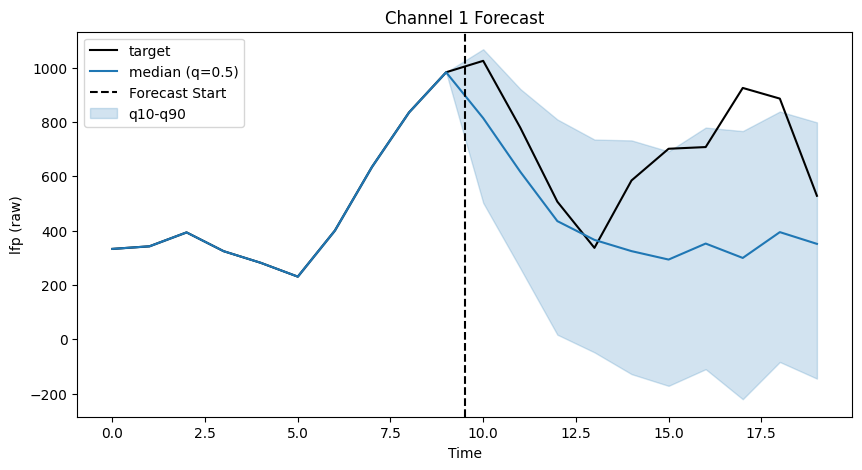

In [9]:
@torch.no_grad()
def plot_channel_quantiles(model, data_loader, channel_idx=1, device=DEVICE, init_steps=10, denorm=True):
    model.eval()
    batch = next(iter(data_loader)).to(device)
    future = batch.shape[1] - init_steps
    x_in = torch.cat([
        batch[:, :init_steps, :, :],
        batch[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)

    t_in = build_time_tensor(x_in)
    out = model(x_in, t_in)
    Q = len(quantiles)
    y_hat_q = out[..., :Q]

    # 填補前 10 步為已知歷史
    y_hat_q[:, :init_steps, :, :] = batch[:, :init_steps, :, 0].unsqueeze(-1)

    y_true = batch[0, :, channel_idx, 0]
    y_q10 = y_hat_q[0, :, channel_idx, quantiles.index(0.1)]
    y_q50 = y_hat_q[0, :, channel_idx, quantiles.index(0.5)]
    y_q90 = y_hat_q[0, :, channel_idx, quantiles.index(0.9)]

    if denorm:
        y_true = denorm_feature0(y_true, channel_idx=channel_idx)
        y_q10 = denorm_feature0(y_q10, channel_idx=channel_idx)
        y_q50 = denorm_feature0(y_q50, channel_idx=channel_idx)
        y_q90 = denorm_feature0(y_q90, channel_idx=channel_idx)
        ylabel = "lfp (raw)"
    else:
        y_true = y_true.detach().cpu().numpy()
        y_q10 = y_q10.detach().cpu().numpy()
        y_q50 = y_q50.detach().cpu().numpy()
        y_q90 = y_q90.detach().cpu().numpy()
        ylabel = "lfp (normalized)"

    plt.figure(figsize=(10, 5))
    plt.plot(y_true, label="target", color="black")
    plt.plot(y_q50, label="median (q=0.5)", color="tab:blue")
    plt.fill_between(np.arange(len(y_q50)), y_q10, y_q90, color="tab:blue", alpha=0.2, label="q10-q90")
    plt.axvline(x=init_steps-0.5, color="black", linestyle="--", label="Forecast Start")
    plt.title(f"Channel {channel_idx} Forecast")
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

# 繪製通道 1 的預測結果
plot_channel_quantiles(model, test_data_loader, channel_idx=1)